**Import Libraries and Modules**

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

**Import train and test Data**

In [2]:
train= pd.read_csv('../input/titanic/train.csv')
test= pd.read_csv('../input/titanic/test.csv')

**Data Descriptons**

Survival: 0 = No, 1 = Yes

Pclass (Ticket class): 1 = 1st, 2 = 2nd, 3 = 3rd

Sex: Sex

Age: Age in years

SibSp: number of siblings/spouses aboard the Titanic

Parch: number of parents/children aboard the Titanic

Ticket: Ticket number

Fare: Passenger fare

Cabin: Cabin number

Embarked: Port of Embarkation, C = Cherbourg, Q = Queenstown, S = Southampton

**Let us analyze train and test data**

In [3]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.shape

(891, 12)

In [7]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [8]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
test.shape

(418, 11)

In [10]:
test.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

**Now let's find out Null values**

In [11]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

**There are null values in train datasets**. **Let us fill the null values with mean, median or mode according to the requirements.**


In [13]:
train['Age'].median()

28.0

In [14]:
train['Embarked'].mode()[0]

'S'

In [15]:
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

In [16]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

**Let us remove unwanted columns from train data set**

In [17]:
train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [18]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


**Let us remove unwanted columns from test data set**

In [19]:
test.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [20]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [21]:
test.isnull().sum()

Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64

**Let us fill the null values with mean, median or mode according to the requirements.**

In [22]:
test['Age'].median()

27.0

In [23]:
test['Embarked'].mode()[0]

'S'

In [24]:
test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

In [25]:
test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

**There are no null values in both train and test datasets********

**Now, let us find unique values in train and test data sets**

In [26]:
train['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

In [27]:
train['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [28]:
train['Sex'].value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [29]:
train['SibSp'].value_counts()

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

In [30]:
train['Parch'].value_counts()

0    678
1    118
2     80
3      5
5      5
4      4
6      1
Name: Parch, dtype: int64

In [31]:
train['Embarked'].value_counts()

S    646
C    168
Q     77
Name: Embarked, dtype: int64

In [32]:
test['Pclass'].value_counts()

3    218
1    107
2     93
Name: Pclass, dtype: int64

In [33]:
test['Sex'].value_counts()

male      266
female    152
Name: Sex, dtype: int64

In [34]:
test['SibSp'].value_counts()

0    283
1    110
2     14
3      4
4      4
8      2
5      1
Name: SibSp, dtype: int64

In [35]:
test['Parch'].value_counts()

0    324
1     52
2     33
3      3
4      2
9      2
5      1
6      1
Name: Parch, dtype: int64

In [36]:
test['Embarked'].value_counts()

S    270
C    102
Q     46
Name: Embarked, dtype: int64

**Let us find outliers in train and test data**

<AxesSubplot:>

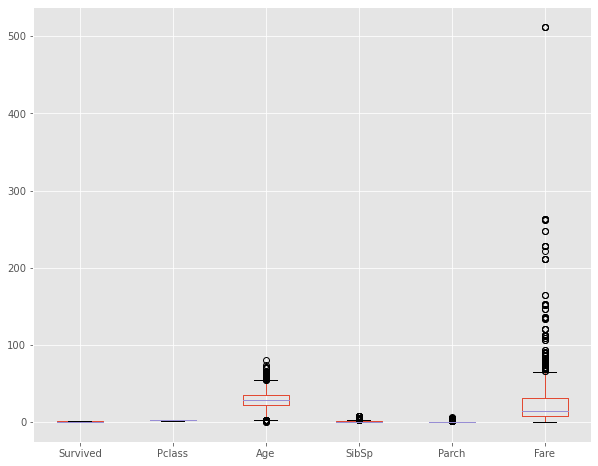

In [37]:
train.plot(kind='box', figsize=(10,8))

**There are outliers in Age, SibSp, Parch and Fare variables. Let us use clip() function to remove outliers**

In [38]:
column_name= ['Age', 'SibSp', 'Parch', 'Fare']

train[column_name]= train[column_name].clip(lower= train[column_name].quantile(0.15), upper= train[column_name].quantile(0.85), axis=1)

**Dropping Parch column because almost 60-70% values are 0**

In [39]:
train.drop(columns=['Parch'], axis=1, inplace=True)

<AxesSubplot:>

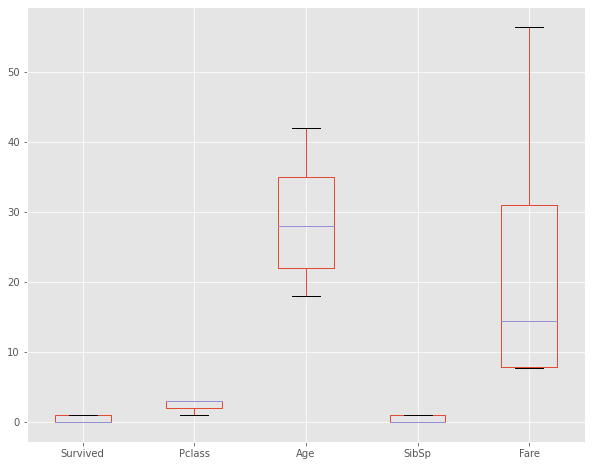

In [40]:
train.plot(kind='box', figsize= (10,8)) 

**There are no outliers in train dataset. Let's do the same process of test data set.**

<AxesSubplot:>

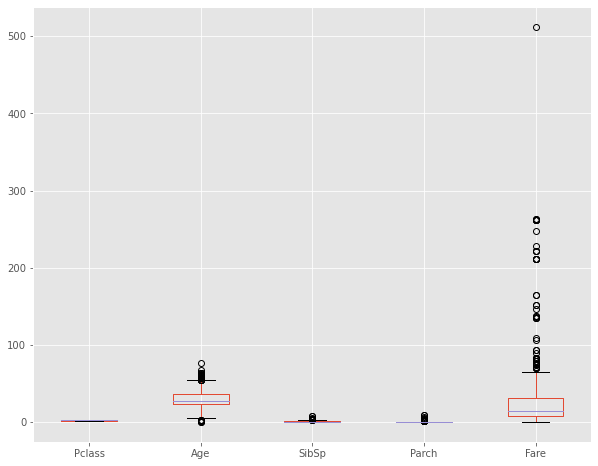

In [41]:
test.plot(kind='box', figsize= (10,8))

In [42]:
test[column_name]= test[column_name].clip(lower= test[column_name].quantile(0.15), upper= test[column_name].quantile(0.85), axis=1)

test.drop(columns=['Parch'], axis=1, inplace=True)

<AxesSubplot:>

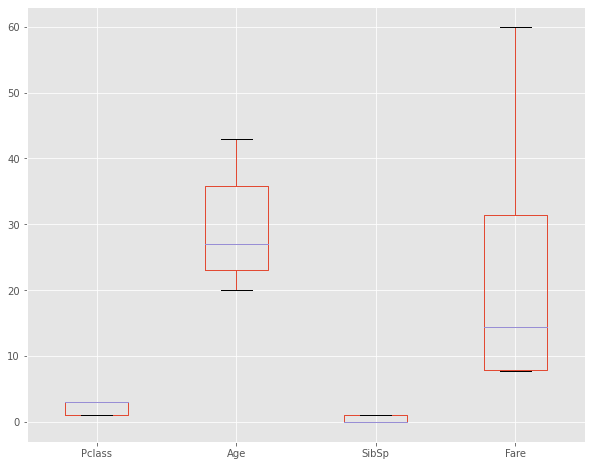

In [43]:
test.plot(kind='box', figsize= (10,8))

**Now, there are no outliers in the test dataset.**

**Let us do some Data Visualization**

<AxesSubplot:xlabel='Sex', ylabel='Survived'>

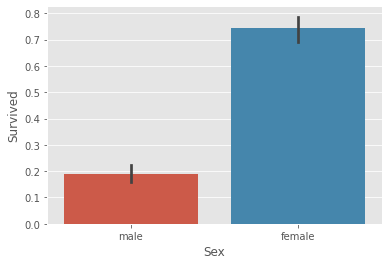

In [44]:
sns.barplot(x="Sex", y="Survived", data=train)

**As it clearly visible Females have the highest chances for survival**

<AxesSubplot:xlabel='Pclass', ylabel='Survived'>

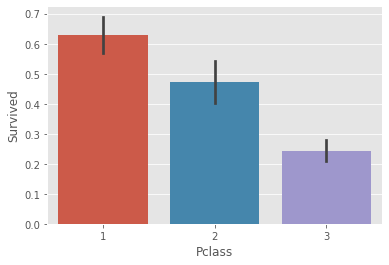

In [45]:
sns.barplot(x="Pclass", y="Survived", data=train)

**As it states, people from class 1 have higher chances of survival**

<AxesSubplot:xlabel='SibSp', ylabel='Survived'>

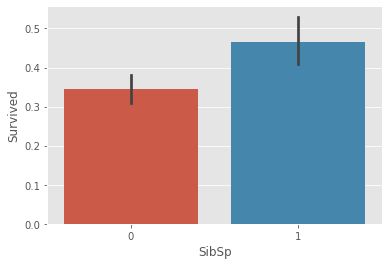

In [46]:
sns.barplot(x="SibSp",y="Survived", data=train)

**People with more siblings have less chance of survival**

<AxesSubplot:xlabel='Survived', ylabel='count'>

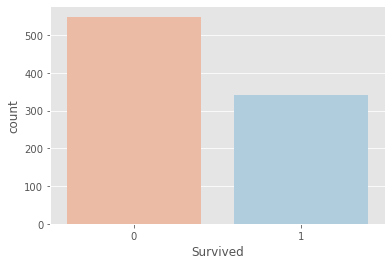

In [47]:
sns.countplot(x="Survived", data=train, palette='RdBu')

**Feature Encoding**

In [48]:
train= pd.get_dummies(train, columns=['Pclass', 'Sex', 'Embarked' ], drop_first= True)

test= pd.get_dummies(test, columns=['Pclass', 'Sex', 'Embarked' ], drop_first= True)

In [49]:
train.head()

,Survived,Age,SibSp,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,7.7500,0,1,1,0,1
1,1,38.0,1,56.4958,0,0,0,0,0
2,1,26.0,0,7.9250,0,1,0,0,1
3,1,35.0,1,53.1000,0,0,0,0,1
4,0,35.0,0,8.0500,0,1,1,0,1


In [50]:
test.head()

,Age,SibSp,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,34.5,0,7.8292,0,1,1,1,0
1,43.0,1,7.7500,0,1,0,0,1
2,43.0,0,9.6875,1,0,1,1,0
3,27.0,0,8.6625,0,1,1,0,1
4,22.0,1,12.2875,0,1,0,0,1


**Let us build Machine Learning Model**

**Split data into train and tests set**

In [51]:
X_train = train.drop('Survived',axis=1)
Y_train = train['Survived']
X_test = test

In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=5, random_state=1)

In [53]:
predictions = rf.predict(X_test)

In [54]:
test_df = pd.read_csv('../input/titanic/test.csv')

In [55]:
output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [56]:
output.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [57]:
output.tail()

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,0
